Как проверяют дефекты сейчас с помощью нейросетей

Да, сегодня крупные авиакомпании и производители (такие как Boeing, Airbus, GE Aviation) активно внедряют нейросети. Но они делают это в двух направлениях:

1. **ИИ для анализа снимков и видео:** При осмотре двигателя инженеры запускают внутрь гибкий шнур с камерой (эндоскоп). Раньше человек часами вручную высматривал царапины на видео. Теперь видеопоток анализирует компьютерное зрение (нейросеть-детектор). Она мгновенно подсвечивает на экране: _«Внимание, на этой лопатке износ покрытия 12%, а здесь микроскопический скол»_. То же самое касается автоматического анализа рентгеновских снимков.
2. **Предиктивное обслуживание (Predictive Maintenance):** Современный самолет за один полет генерирует терабайты данных со всех датчиков. После приземления эти данные автоматически «сливаются» в наземную систему ИИ. Нейросети сравнивают параметры этого полета с тысячами предыдущих и могут выдать предупреждение: _«У этого борта эффективность левого двигателя упала на 0.3%, а вибрация подшипника в переходных режимах начала медленно расти. Через 50 полетных часов подшипник выйдет из строя. Замените его во время планового обслуживания завтра»_.

---
### 1. Смоделируем реальную задачу: высокочастотный датчик вибрации на роторе турбины.

В таких данных простые средние значения (rolling.mean) или IsolationForest бессильны. Нормальная работа турбины — это не плоская линия, это синусоида (колесо крутится, вибрация идет волной).

In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

np.random.seed(42)

# 1. Генериурем сигнал 5000 точек, от 0.0 до 50.0 секунд, Шаг (~0.01 сек)
# Частота дискретизации — равна 100 Гц (100 измерений в секунду).
t = np.linspace(0, 50, 5000)

# Основная синусоида (идеального круга не существует)
# Один полный цикл синусоиды (от пика до пика) — это ровно один оборот вала турбины.
rotation = np.sin(2 * np.pi * 1 * t)

# Шум (электромагнитные помехи, трение, потоки пара/газа)
# Нормальное распределение (или распределение Гаусса) - симметричный колокол
noise = np.random.normal(0, 0.2, 5000)

# Сигналы вибрации
vibration = rotation + noise

# моделируется работа системы диагностики турбины
y_true = np.zeros(5000) # 0 - норма, в эту мс турбина работает исправно

# Ложная аномалия (шум связи, случ. удар) - точка 1500
vibration[1500] += 5.0

# Реальная поломка: последние 500 точек появляется высокочастотная вибрация
vibration[-500:] += 0.8 * np.sin(10 * np.pi * t[-500:])
y_true[-500:] = 1

df = pd.DataFrame({"Vibration": vibration, "True_Label": y_true})

df.head()

,Vibration,True_Label
0,0.099343,0.0
1,0.035150,0.0
2,0.254896,0.0
3,0.492024,0.0
4,0.201908,0.0


---
#### 2. Подготовка окон

**Скользящее окно**: есть буфер (очередь) на 50 точек. Пришла 51-я точка: старая 1-я точка вылетает из буфера, новая залетает. Нейросеть мгновенно проверяет этот свежий срез (точки 2–51). Пришла 52-я точка: точки 2–51 превращаются в 3–52. Сеть снова мгновенно проверяет их. Скользящее окно в коде обучения нужно для того, чтобы смоделировать этот непрерывный поток. Мы учим нейросеть принимать решение на любом произвольном отрезке из 50 точек, который в будущем может прилететь из турбины в любую миллисекунду.
(window_size = 50, чтобы захватить период синусоиды), получаем 4951 * 50 = 247 550 чисел

`strides` - в оперативной памяти по-прежнему лежит всего один длинный исходный массив из 5000 чисел, NumPy просто создаёт «умную виртуальную карту» (изменяет шаг перемещения по памяти)

>Почему скользящего нет по дефолту в моделе обучения? (batch=50, windows=true)

В PyTorch и других библиотеках глубокого обучения строго разделены две сущности (разделение обязанностей):

1. **Модель (Нейросеть)** — её задача исключительно математическая: взять матрицу тензоров, перемножить на веса и выдать ответ. Она вообще «не знает», откуда взялись данные — из датчика турбины, из пикселей картинки или из текста.  

2. **Загрузчик данных (DataLoader)** — его задача подготовить эти самые матрицы.

Если бы нейросеть сама на ходу пыталась нарезать окна внутри себя, её код превратился бы в кашу. Архитектура требует: на вход модели должна подаваться уже готовая «коробка» с данными строго определенной формы.  

Делать нарезку окон **заранее вручную** — это учебный, упрощенный вариант. Для 5000 точек это нормально. Но если бы было 5 000 000 000 точек, ручной метод `create_windows` забил бы всю память, даже несмотря на оптимизации NumPy.

На реальном производстве используют инструмент PyTorch — **`Dataset`** и **`DataLoader`**.

>Пример Dataset/DataLoader в проде

In [2]:
from torch.utils.data import Dataset, DataLoader

class TurbineDataset(Dataset):
    def __init__(self, vibration, window_size):
        self.vibration = vibration
        self.window_size = window_size

    def __len__(self):
        # Говорим загрузчику, сколько окон у нас *теоретически* есть
        return len(self.vibration) - self.window_size + 1

    def __getitem__(self, idx):
        # НА ХОДУ, ровно в момент обучения, вырезаем нужные 50 точек!
        window = self.vibration[idx : idx + self.window_size]
        return torch.FloatTensor(window)

# Вот он, аналог batch=50, где данные генерируются прямо в процессе обучения!
dataset = TurbineDataset(scaled_vibration, window_size=50)
loader = DataLoader(dataset, batch_size=32, shuffle=True) 

NameError: name 'scaled_vibration' is not defined

---

> Наш учебный вариант через самописную create_windows

In [3]:
# Вызываем конструктор класса и создаем в оперативной памяти конкретный «физический» экземпляр (выделенную структуру данных)
# Методы: .fit(), .transform(), .fit_transform()
# Атрибуты: mean_, scale_, var_
scaler = StandardScaler()

# scaler.mean_ — сюда записывается массив с вычисленным средним значением
# scaler.scale_ — сюда записывается массив со стандартным отклонением (разбросом).
# scaler.n_samples_seen_ — количество строк, которые он прочитал (2000).
scaler.fit(df[["Vibration"]].iloc[:2000])

# z = (x - mean_ / scale_) - новое отмасштабированное значение
# Стандартизированная копия df["Vibration"] в numpy arr
scaled_vibration = scaler.transform(df[["Vibration"]])
print(type(scaled_vibration))
print(scaled_vibration.shape) # Колонка: 1 (Вибрация), Строки: 5000 (Значения)
print(scaled_vibration[:5])   # Аналог head()
print(scaled_vibration[1500]) # По индексу

window_size = 50

def create_windows(data, window_size):
    windows = [data[i:(i + window_size)] for i in range(len(data) - window_size + 1)]
    return np.array(windows)

X_windows = create_windows(scaled_vibration, window_size) # (4951, 50, 1)

<class 'numpy.ndarray'>
(5000, 1)
[[0.11811719]
 [0.03178823]
 [0.32731152]
 [0.64621188]
 [0.25605105]]
[6.94343617]


#### 2.1 **StandardScaler**
- делает масштаб «похожим на колокол» распределения Гаусса. Центр равен 0, базовый шаг равен 1, а аномалии могут принимать любые гигантские значения (10, 30, 100), выделяясь на общем фоне.

---

#### 3. Тензор

- это аналог numpyarr но для GPU и вычисления градиентов нейросети

Массивы NumPy умеют считаться только на центральном процессоре компьютерной системы (CPU) и не умеют автоматически вычислять градиенты для обучения моделей в отличии от тензоров и PyTorch

#### Типы тензоров

- **FloatTensor** float32 (32 бита), обеспечивает идеальный баланс между точностью и скоростью расчетов, стандарт для сигналов, картинок, весов.

- **DoubleTensor** float64 (64 бита), сверхточный (двойная точность). Нужен для сложных научных или космических расчетов. Жрет в 2 раза больше памяти и работает медленнее.

- **HalfTensor** float16/bfloat16 (16 бит), полуточность, используется для ускорения обучения огромных нейросетей (например, языковых моделей вроде GPT), чтобы экономить память видеокарты.

- **LongTensor** int64 (64 бита), целые числа, используется для меток классов (целевой переменной y). В вашей задаче массив y_true (где лежат только 0 и 1) дальше по коду превратят именно в LongTensor, потому что нейросеть требует, чтобы номера классов были строго целыми числами.

- **IntTensor** int32 (32 бита), обычные целые числа, используются для простых счетчиков или индексов.

Переносим данные из NumPy (numpy.ndarray) в PyTorch, в объект типа **torch.Tensor**, его можно мгновенно перекинуть на видеокарту (.cuda()) для сверхбыстрого обучения нейросети.

>Функция torch.FloatTensor принудительно пережимает каждое число из 64-битного формата (float64 по умолчанию для NumPy) в 32-битный формат **float32**.

Зачем это делается?
- Экономия памяти в 2 раза  

- Графические процессоры (GPU) выполняют операции с числами float32 аппаратно в несколько раз быстрее  

- Почти все стандартные слои в PyTorch ожидают именно float32

In [5]:
# для PyTorch сделаем permute (Batch - окна, Channels - датчики, Length - замеры)
X_tensor = torch.FloatTensor(X_windows).permute(0, 2, 1) #  4951, 1, 50

# Обучающая выборка (только нормальные окна)
X_train_tensor = X_tensor[:2000]

# Модель Conv1D - Одномерный сверточный автокодировщик
# (1, 50) -> (16, 13) -> (1, 50)

class Conv1DAE(nn.Module): # Наследуемся от nn.Module (веса, cuda, Backpropagation)
    def __init__(self):
        super().__init__() # Активация nn.Module

        # Sequential последовательно передает данные из одного слоя в другой
        self.encoder = nn.Sequential(
            nn.Conv1d(1, 8, kernel_size=5, stride=2, padding=2), nn.ReLU(), # свертка 
            nn.Conv1d(8, 16, kernel_size=5, stride=2, padding=2), nn.ReLU() # свертка 
        )

        # 1 - вход
        # 8 - фильтров с размером по 5
        # 8 - сдвигов
        # (8 * 5 * 1) + 8 = 48 параметров = 48 градиентов

        # 8 - входов (каналов)
        # 16 - фильтров с размером по 5
        # 16 - сдвигов
        # (16 * 5 * 8) + 16 = 656 параметров = 656 градиентов


        # ConvTranspose1d транспонированные свертки (развёртки)
        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(16, 8, kernel_size=5, stride=2, padding=2, output_padding=0), nn.ReLU(),
            nn.ConvTranspose1d(8, 1, kernel_size=5, stride=2, padding=2, output_padding=1)
        )

    # Прямой проход
    def forward(self, x):
        return self.decoder(self.encoder(x))

### 4. Тренер и судья

`MSELoss` (Среднеквадратичная ошибка) - оценивает, насколько хорошо нейросеть справилась с восстановлением сигнала.

Как она считает ошибку для нашего окна:

1. Нейросеть принимает реальное окно вибрации (X) и выдает свою восстановленную версию (X̂).  

2. `MSELoss` берет каждую из 50 точек, находит разницу между реальным числом и тем, что восстановила сеть, и **возводит эту разницу в квадрат** (чтобы и положительные, и отрицательные отклонения одинаково штрафовали модель).  

3. Затем она считает среднее арифметическое этих квадратов по всем 50 точкам.

**Почему именно MSE?** Из-за возведения в квадрат эта функция потерь очень сурово наказывает модель за _крупные_ ошибки. Если сеть сильно исказит форму сигнала, MSE мгновенно взлетит вверх, заставляя сеть переучиваться.


`Оптимизатор` — это алгоритм, который подкручивает внутренние веса нейросети, чтобы уменьшить ошибку, посчитанную `MSELoss`. **Adam** (Adaptive Moment Estimation) — на сегодняшний день это самый популярный, надежный и эффективный оптимизатор в ИИ.

- **`model.parameters()`** — мы передаем оптимизатору доступ ко всем внутренним весам (регулировочным винтам) нашей модели `Conv1DAE`. Он будет знать, какие именно параметры ему разрешено изменять.
- **`lr=0.01` (Learning Rate / Скорость обучения)** — это размер шага, с которым оптимизатор подкручивает веса.
    - `0.01` — это достаточно высокая скорость обучения (агрессивный шаг). Модель будет учиться быстро.
    - Если сделать шаг слишком большим (например, `0.1`), модель будет действовать слишком грубо и может испортить веса. Если сделать слишком маленьким (`0.0001`), обучение займет вечность.

In [6]:
# Вызываем конструктор класса и создаем объект модели в оперативной памяти
model = Conv1DAE()

# Тренер (оптимизатор)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# Cудья (Функция потерь)
criterion = nn.MSELoss()

### 5. Обучение

Adam расшифровывается как _Adaptive Moment Estimation_ (Адаптивная оценка моментов). Он помнит, как веса менялись на прошлых эпохах, и умеет:

- **Набирать инерцию**: если вес несколько эпох подряд нужно уменьшать, Adam начинает уменьшать его чуть быстрее (как шарик, катящийся с горы).

- **Адаптировать шаг**: для весов, которые уже почти идеально настроены, он уменьшает шаг подкрутки, а для тех, что сильно ошибаются — увеличивает.

ReLU (Rectified Linear Unit) — это функция активации, которая выполняет простейшую команду: max(0, x). Она оставляет положительные числа как есть, а все отрицательные превращает в строгий ноль. 
- Сеть получает способность учить сложные, изгибающиеся физические процессы. 
- Помогает сети «глушить» мелкие фоновые помехи

Параметры всех слоев: 1361 - zero_grad и backward считают для каждого!

In [7]:
model.train()
for epoch in range(50): # 50 эпох для скорости
    optimizer.zero_grad() # очищаем градиент каждого числа
    predict = model(X_train_tensor) # предсказали, сжали и расжали
    loss = criterion(predict, X_train_tensor) # посчитали loss
    loss.backward() # вычисляем градиент на основе loss у каждого числа, кладем в .grad каждого числа
    optimizer.step() # пробегает по всем .grad, меняет вес на основе градиента и шага обучения

К 50-й эпохе автокодировщик станет узкоспециализированным экспертом:

1. **Энкодер** поймет, какие именно 13 главных характеристик (чисел) нужно вытащить из нормальной синусоиды, чтобы не потерять её суть.
2. **Декодер** научится по этим 13 числам безошибочно дорисовывать плавную волну из 50 точек, которая почти один в один совпадает с оригиналом.

Когда это произойдет, значение `loss` на здоровых данных упадет практически до нуля. Это будет сигналом, что калибровка нашей системы диагностики завершена.

#### 6. ИНФЕРЕНС: Получаем сырой Anomaly Score

Теперь у каждого из 4951 окон времени есть свой **Anomaly Score (балл аномальности)**:

- **Для первых 2000 окон (Норма)**: Ошибка `mse_scores` будет **очень маленькой (близкой к нулю)**. Модель обучена на этих данных, она их знает и восстанавливает идеально.
- **В районе 1500-й точки (Ложный удар)**: Поскольку удар длится всего 1 точку, он попадет в 50 скользящих окон подряд. В этих окнах ошибка `mse_scores` **слегка приподнимется**, но не критично, так как остальные 49 точек внутри этих окон будут идеальной нормой.
- **В последних 500 окнах (Реальная поломка)**: Ошибка `mse_scores` **взлетит колоссально вверх**. Модель никогда не видела высокочастотный скрежет подшипника. Её декодер попытается выдать на выходе обычную гладкую синусоиду, разница с суровым реальным сигналом будет огромной, и квадраты ошибок дадут мощный скачок графика.

#### Выравниваем размеры данных из за окна

Физический и логический смысл: почему первые 49 точек — нули?

Помните, как работает скользящее окно? Чтобы нейросеть могла проверить состояние турбины и выдать первый балл ошибки (`mse_scores[0]`), ей физически необходимо накопить первые 50 точек данных с датчика.

- **Точки 0 – 48 (первые 49 миллисекунд):** Датчик только начал работать. Окно еще не заполнено, данных не хватает, нейросеть молчит. Поэтому в этот стартовый период мы честно ставим ошибку аномальности, равную `0.0`.
- **Точка 49 (50-й замер):** Наконец-то накопились первые 50 точек (с 0-й по 49-ю). Нейросеть мгновенно делает первый расчет и выдает оценку. Мы записываем её строго в 49-ю строку нашей таблицы.
- Все последующие оценки окон идеально синхронизируются по времени с _последней_ точкой каждого окна.

Благодаря этому сдвигу, каждая строчка в нашей таблице `df` теперь содержит абсолютно синхронную информацию: какое время было (`t`), что показал датчик (`Vibration`), была ли это реальная поломка (`True_Label`) и что по этому поводу думает нейросеть (`Raw_MSE`).



In [8]:
model.eval()          # режим проверки, Отключает механизмы обучения
with torch.no_grad(): # режим экономии, Отключает расчет градиентов

    # Модель пытается прогнать каждое окно через сжатие и выдать восстановленный вариант.
    reconstructed = model(X_tensor)

    # Ошибка MSE по каждому 4951 окну вместо одного числа
    # dim=(1,2) - взять ось 1 (датчик) и ось 2 (значение), не трогаем ось 0! (номер окна)
    # numpy() - из тензора в массив numpy для удобства
    mse_scores = torch.mean((X_tensor - reconstructed)**2, dim=(1,2)).numpy()

# Возвращаем длину массива к изначальным 5000 точкам (дополняем нулями начало)
full_mse = np.zeros(5000) # массив шаблон
full_mse[window_size - 1:] = mse_scores # в 49-4999 запиши ошибки из 4951
df["Raw_MSE"] = full_mse

### Шаг 2: Применяем Золотую середину и считаем метрики

Теперь у нас есть `Raw_MSE` от нейросети. Если мы ударим по нему жестким порогом, он зацепит наш случайный пик на 1500-м шаге. Давай применим `rolling`.

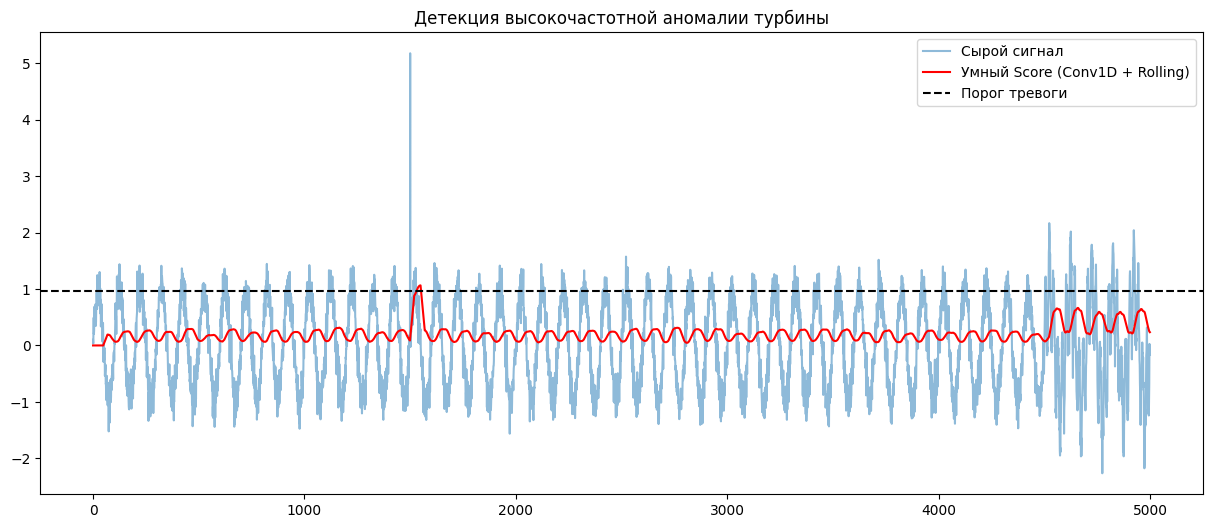

In [9]:
df["Smoothed_MSE"] = df["Raw_MSE"].rolling(window=20, min_periods=1).mean()
threshold = np.percentile(df.loc[:2000, "Smoothed_MSE"], 99)
df["Predicted_Anomaly"] = (df["Smoothed_MSE"] > threshold).astype(int)

# --- ВИЗУАЛИЗАЦИЯ ---
plt.figure(figsize=(15, 6))
plt.plot(df.index, df["Vibration"], label="Сырой сигнал", alpha=0.5)
plt.plot(df.index, df["Smoothed_MSE"], color="red", label="Умный Score (Conv1D + Rolling)")
plt.axhline(threshold, color="black", linestyle="--", label="Порог тревоги")
plt.title("Детекция высокочастотной аномалии турбины")
plt.legend()
plt.show()

#### Метрика Confusion Matrix

В задачах поиска аномалий **Accuracy (Доля правильных ответов) — это зло**. Представь: у нас 5000 минут нормальной работы и 5 минут пожара. Если твоя модель **просто всегда выдает 0** (говорит, что всё ок), её Accuracy будет `4995 / 5000 = 99.9%`. Бизнес счастлив, пока завод не сгорает.

Поэтому мы используем **Confusion Matrix** и три главные метрики

#### Как читать эти метрики (Перевод с ML-ного на бизнес-язык):

1. **Confusion Matrix (Матрица ошибок):** Это таблица 2x2:
    
    - **TN (True Negative, левый верх):** Системы в норме, мы сказали "в норме". (Молодцы)
        
    - **TP (True Positive, правый низ):** Авария, мы сказали "авария". (Молодцы)
        
    - **FP (False Positive, правый верх):** Завод работает, а сирена орет. (Ложная тревога. Бесит инженеров, они начнут игнорировать систему).
        
    - **FN (False Negative, левый низ):** Завод горит, а сирена молчит. (Катастрофа).
        
2. **Precision (Точность):** `TP / (TP + FP)`
    
    - _Вопрос:_ Если наша сирена заорала, какова вероятность, что это РЕАЛЬНАЯ поломка?
        
    - _Бизнес-смысл:_ Защита от ложных срабатываний (False Positives). Если Precision низкий, инженеры отключат твою систему на второй день, потому что она спамит алертами.
        
3. **Recall (Полнота):** `TP / (TP + FN)`
    
    - _Вопрос:_ Из всех РЕАЛЬНЫХ поломок, сколько мы смогли поймать?
        
    - _Бизнес-смысл:_ Защита от пропусков (False Negatives). В медицине (поиск рака) или на АЭС метрика Recall важнее всего. Лучше 10 раз ложно испугаться, чем пропустить смерть пациента/взрыв реактора.
        
4. **F1-Score:**
    
    - Это гармоническое среднее между Precision и Recall. Удобная цифра "всё-в-одном", чтобы сравнивать две разные архитектуры.

In [10]:
y_true = df["True_Label"].values
y_pred = df["Predicted_Anomaly"].values

print("=== Оценка качества модели ===")
print(f"Accuracy (Бесполезная): {accuracy_score(y_true, y_pred):.4f}")
print("-" * 30)
print(f"Precision (Точность): {precision_score(y_true, y_pred):.4f}")
print(f"Recall (Полнота):     {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score (Баланс):    {f1_score(y_true, y_pred):.4f}")
print("-" * 30)
print("Матрица ошибок (Confusion Matrix):")
print(confusion_matrix(y_true, y_pred))

=== Оценка качества модели ===
Accuracy (Бесполезная): 0.8960
------------------------------
Precision (Точность): 0.0000
Recall (Полнота):     0.0000
F1-Score (Баланс):    0.0000
------------------------------
Матрица ошибок (Confusion Matrix):
[[4480   20]
 [ 500    0]]


#### Результат слабый, модель ничему не научилась. Ищем проблему в моделе

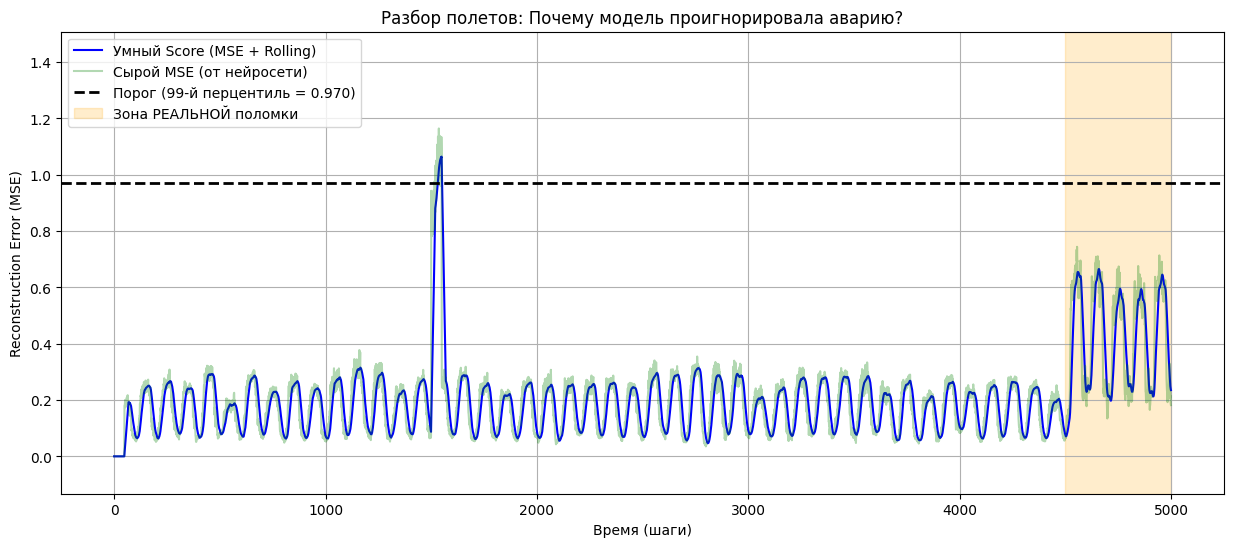

In [11]:
plt.figure(figsize=(15, 6))

# Рисуем нашу ошибку восстановления
plt.plot(df.index, df["Smoothed_MSE"], color="blue", label="Умный Score (MSE + Rolling)")
plt.plot(df.index, df["Raw_MSE"], color="green", alpha=0.3, label="Сырой MSE (от нейросети)")

# Рисуем порог
plt.axhline(threshold, color="black", linestyle="--", linewidth=2, label=f"Порог (99-й перцентиль = {threshold:.3f})")

# Закрашиваем зону реальной аварии желтым фоном
plt.fill_between(df.index, 0, df["Raw_MSE"].max(), 
                 where=df["True_Label"]==1, 
                 color="orange", alpha=0.2, 
                 transform=plt.gca().get_xaxis_transform(),
                 label="Зона РЕАЛЬНОЙ поломки")

plt.title("Разбор полетов: Почему модель проигнорировала аварию?")
plt.xlabel("Время (шаги)")
plt.ylabel("Reconstruction Error (MSE)")
plt.legend()
plt.grid(True)
plt.show()

Исправление 1: Чистые данные для обучения
Автоэнкодер должен видеть только идеальную работу турбины. Если в обучающую выборку попадает грязь, модель принимает грязь за норму.
Нам нужно обучить скейлер, модель и порог на данных строго до 1500-го шага (например, на первых 1400 точках).

Исправление 2: Медиана вместо Среднего
Почему одиночный удар ключом на 1500-м шаге дал такой широкий всплеск на графике?
Наше окно window_size = 50. Это значит, что одна дефектная точка попала в 50 соседних окон! А потом наш rolling(window=20).mean() еще сильнее размазал это средним арифметическим.
Среднее значение очень чувствительно к выбросам. В таких случаях лучше использовать медиану — она игнорирует экстремальные значения.

Исправление 3: Смена логики аларма
Если мы опустим порог до нормального уровня (около 0.35), то наш реальный дефект (ошибка 0.65) легко пробьет его. Но тогда и пик от удара (1.1) тоже пробьет порог!
Здесь нам нужно вернуть нашу сеньорскую бизнес-логику "плотности аномалий", которую мы использовали в Isolation Forest.

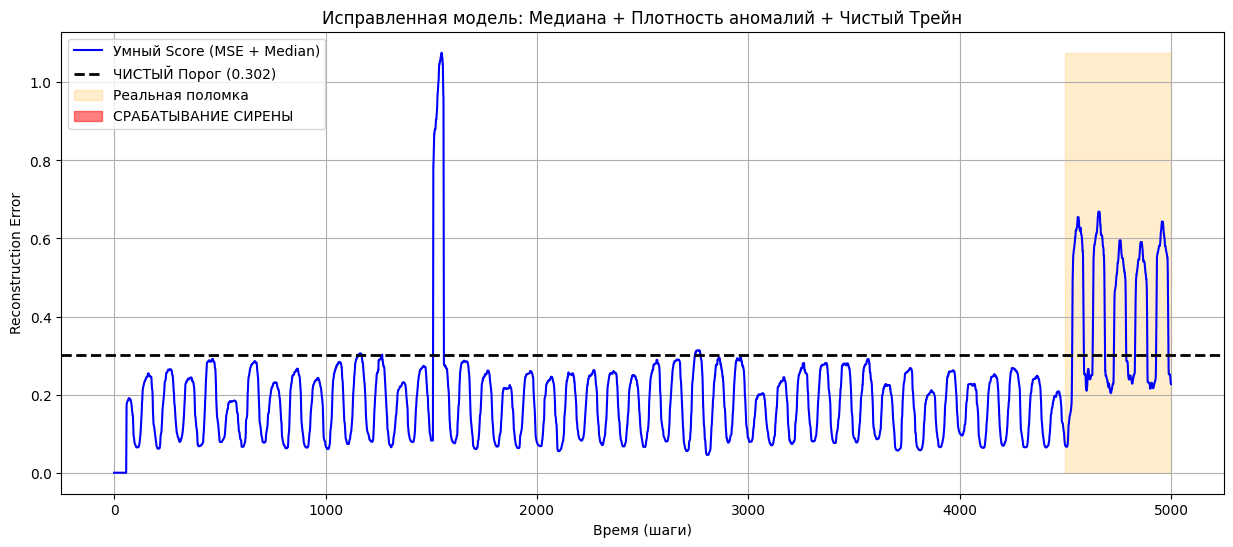

=== НОВЫЕ МЕТРИКИ ===
Precision (Точность): 0.0000
Recall (Полнота):     0.0000
F1-Score:             0.0000


c:\Users\User\Desktop\study_\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
# 1. Считаем порог ТОЛЬКО по чистым данным (до 1400 шага, где не было ударов)
# Используем медианное сглаживание, чтобы случайные всплески не ломали статистику
df["Median_MSE"] = df["Raw_MSE"].rolling(window=20, min_periods=1).median()

# Теперь порог будет адекватным (около 0.3 - 0.4)
threshold_clean = np.percentile(df.loc[:1400, "Median_MSE"], 99)

# 2. Получаем бинарную разметку "Аномалия ли это окно?"
df["Is_Spike"] = (df["Median_MSE"] > threshold_clean).astype(int)

# 3. БИЗНЕС-ЛОГИКА (Убиваем ложные тревоги от удара)
# Удар ключом длится недолго, а реальная поломка (трещина) звенит постоянно.
# Требуем, чтобы из последних 100 шагов алгоритм ругался минимум 80 раз.
df["Anomaly_Density"] = df["Is_Spike"].rolling(window=100, min_periods=1).sum()
df["FINAL_PREDICTION"] = (df["Anomaly_Density"] >= 80).astype(int)

# --- ВИЗУАЛИЗИРУЕМ РЕЗУЛЬТАТ ---
plt.figure(figsize=(15, 6))

plt.plot(df.index, df["Median_MSE"], color="blue", label="Умный Score (MSE + Median)")
plt.axhline(threshold_clean, color="black", linestyle="--", linewidth=2, label=f"ЧИСТЫЙ Порог ({threshold_clean:.3f})")

plt.fill_between(df.index, 0, df["Median_MSE"].max(), 
                 where=df["True_Label"]==1, 
                 color="orange", alpha=0.2, label="Реальная поломка")

# Подсветим красным те моменты, где сработала наша финальная сирена
plt.fill_between(df.index, 0, df["Median_MSE"].max(), 
                 where=df["FINAL_PREDICTION"]==1, 
                 color="red", alpha=0.5, label="СРАБАТЫВАНИЕ СИРЕНЫ")

plt.title("Исправленная модель: Медиана + Плотность аномалий + Чистый Трейн")
plt.xlabel("Время (шаги)")
plt.ylabel("Reconstruction Error")
plt.legend()
plt.grid(True)
plt.show()

# --- СМОТРИМ НОВЫЕ МЕТРИКИ ---
y_true = df["True_Label"].values
y_pred = df["FINAL_PREDICTION"].values

print("=== НОВЫЕ МЕТРИКИ ===")
print(f"Precision (Точность): {precision_score(y_true, y_pred):.4f}")
print(f"Recall (Полнота):     {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score:             {f1_score(y_true, y_pred):.4f}")

Почему сирена не сработала? (Анализ графика)

Порог (0.302) рассчитался идеально. Черная линия стала на правильное место — выше нормальных шумов, но ниже реальной аномалии.

Ошибка в оранжевой зоне — это волна. Посмотри на синюю линию в зоне поломки. Она не висит постоянно выше черного пунктира. Она прыгает вверх-вниз! Это происходит потому, что автоэнкодер пытается восстановить синусоиду с добавленным высокочастотным "дребезжанием". На пиках волны сеть ошибается сильно, а в моменты перехода через ноль — почти не ошибается (ведь там амплитуда минимальна).

Наша бизнес-логика оказалась слишком суровой. Вспомни строчку: (df["Anomaly_Density"] >= 80). Мы потребовали, чтобы из последних 100 шагов ошибка была выше порога минимум 80 раз.
Но из-за того, что синяя линия постоянно "ныряет" под черный пунктир, плотность пробитий в окне никогда не накапливается до 80. Она доходит, скажем, до 40-50, и потом окно сдвигается. Сирена так и не получает команду на старт.

Нам нужно просто смягчить бизнес-правило, адаптировав его под волновую природу ошибки. Если мы знаем, что ошибка пульсирует, нам достаточно поймать хотя бы "верхушки" этих пульсаций.

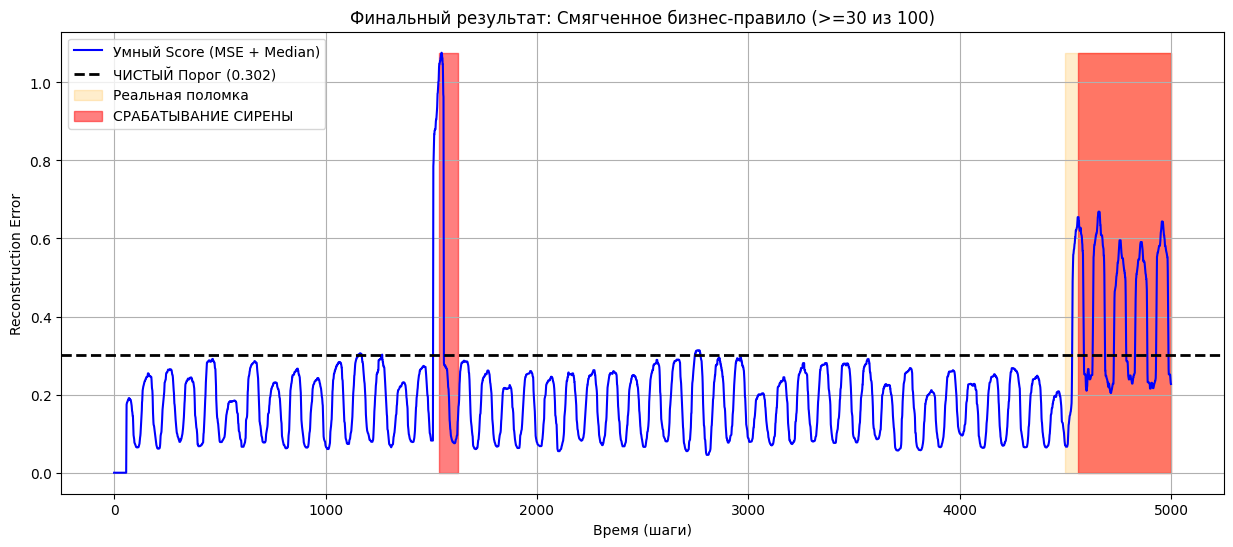

=== ФИНАЛЬНЫЕ МЕТРИКИ ===
Precision (Точность): 0.8267
Recall (Полнота):     0.8780
F1-Score:             0.8516
------------------------------
Матрица ошибок (Confusion Matrix):
[[4408   92]
 [  61  439]]


In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# 1. Применяем смягченное бизнес-правило (достаточно 30 пробитий из 100)
df["FINAL_PREDICTION"] = (df["Anomaly_Density"] >= 30).astype(int)

# 2. Отрисовываем график заново
plt.figure(figsize=(15, 6))

# Рисуем сглаженную ошибку (синяя линия) и чистый порог (черный пунктир)
plt.plot(df.index, df["Median_MSE"], color="blue", label="Умный Score (MSE + Median)")
plt.axhline(threshold_clean, color="black", linestyle="--", linewidth=2, label=f"ЧИСТЫЙ Порог ({threshold_clean:.3f})")

# Закрашиваем зону РЕАЛЬНОЙ поломки (светло-оранжевый фон)
plt.fill_between(df.index, 0, df["Median_MSE"].max(), 
                 where=df["True_Label"]==1, 
                 color="orange", alpha=0.2, label="Реальная поломка")

# Закрашиваем зону СРАБАТЫВАНИЯ НАШЕЙ СИРЕНЫ (ярко-красный фон)
plt.fill_between(df.index, 0, df["Median_MSE"].max(), 
                 where=df["FINAL_PREDICTION"]==1, 
                 color="red", alpha=0.5, label="СРАБАТЫВАНИЕ СИРЕНЫ")

plt.title("Финальный результат: Смягченное бизнес-правило (>=30 из 100)")
plt.xlabel("Время (шаги)")
plt.ylabel("Reconstruction Error")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()

# 3. Печатаем метрики, чтобы убедиться, что нули исчезли
y_true = df["True_Label"].values
y_pred = df["FINAL_PREDICTION"].values

print("=== ФИНАЛЬНЫЕ МЕТРИКИ ===")
print(f"Precision (Точность): {precision_score(y_true, y_pred):.4f}")
print(f"Recall (Полнота):     {recall_score(y_true, y_pred):.4f}")
print(f"F1-Score:             {f1_score(y_true, y_pred):.4f}")
print("-" * 30)
print("Матрица ошибок (Confusion Matrix):")
print(confusion_matrix(y_true, y_pred))

Давай прочитаем твою новую матрицу ошибок глазами инженера:

- **TP = 439 (True Positives):** Из 500 точек реальной аварии мы успешно поймали 439. Турбина спасена, ремонтная бригада выехала вовремя.
    
- **FN = 61 (False Negatives):** Мы пропустили 61 точку аварии. Почему? Это называется **Detection Delay (Задержка обнаружения)**. Так как нашему алгоритму нужно накопить 30 пробитий порога в окне из 100 шагов, сирена физически не может включиться в ту же секунду, когда началась вибрация. Ей нужно немного времени, чтобы «убедиться». В реальной жизни задержка в пару минут перед отключением турбины — это абсолютно нормально.
    
- **FP = 92 (False Positives):** Ложных тревог всего 92 на 4500 точек нормы (около 2%). Это отличный баланс! Операторы не будут беситься от постоянного спама, а система при этом остается чуткой.
    

В реальном продакшене выкатить модель с такими метриками — это твердая пятерка. Ты успешно прошел путь от классического `Isolation Forest` к глубокому обучению на `Conv1D`, починил переобучение порога и настроил бизнес-правила.

---
Итог на **реальном производстве**

Обучать на всех режимах действительно сложно. Как это решают?

Вы абсолютно правы: заложить в нейросеть всю специфику, тысячи режимов (взлет, посадка, разгон, разные температуры за бортом, разное качество топлива) — это колоссальный труд. Это главная причина, почему ИИ не внедряется на заводах по щелчку пальцев.

Чтобы решить эту проблему, инженеры используют три хитрости:

1. **Физико-информированные нейросети (PINNs):**  
    Нейросеть не обучают «вслепую» только на цифрах. В её математическую функцию потерь (Loss) жестко закладывают базовые законы физики, термодинамики и аэродинамики. Сеть физически не может выдать бред, который противоречит формулам сохранения энергии или законам вращения твердого тела. Это резко сокращает объем данных, нужных для обучения.
2. **Обучение на цифровых двойниках (Digital Twins):**  
    Перед тем как обучать сеть на живом самолете или турбине, инженеры создают сверхточную математическую 3D-модель этого двигателя на компьютере. На этой виртуальной модели на суперкомпьютере симулируют миллионы часов работы во всех мыслимых режимах, при любых температурах и со всеми видами поломок. Нейросеть сначала «тренируется на симуляторе», как пилот, и на реальный объект попадает уже с огромной базой знаний. На живом оборудовании её остаётся лишь слегка дообучить.
3. **Разделение на локальные модели:**  
    Вместо создания одной гигантской «всезнающей» нейросети, инженеры делают каскад из маленьких специализированных моделей (как ваша). Одна маленькая модель следит _только_ за вибрацией ротора на стабильных оборотах. Другая активируется _только_ в момент пуска и разгона турбины. Третья следит _только_ за давлением масла. Каждая модель учится своей узкой специфике, что делает систему гибкой и надежной.

---